# 00 — EDA: datos y features causales

Banco de pruebas de detección de regímenes (capa TFM). Este notebook ejecuta el EDA de la **FASE 1**:
- Cobertura y fechas de inicio por serie (set ampliado, **sin imputar**).
- Ventana común resultante y periodos faltantes.
- Estadísticos, **fat tails** (kurtosis), correlaciones.
- Suelos de drawdown del S&P 500 (que alimentan `DRAWDOWN_TROUGHS`).
- Construcción de **features causales** + test de no look-ahead.

Resumen en `docs/memory/01_data_and_eda.md`.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Localizar raíz del repo (contiene src/)
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
from src import data_loader as dl, features as ft, evaluation as ev

raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
print('Panel crudo:', raw.shape, '| union de fechas', raw.index.min().date(), '->', raw.index.max().date())
raw.tail(3)

Panel crudo: (10591, 9) | union de fechas 1985-01-02 -> 2026-06-16


,SP500,VIX,MOVE,TLT,IEF,HYG,GOLD,DXY,YIELD_10Y_3M
date,,,,,,,,,
2026-06-12,7431.459961,17.68,69.360001,85.769997,94.180000,79.940002,386.540009,99.750000,0.869
2026-06-15,NaN,NaN,NaN,85.720001,94.279999,NaN,NaN,NaN,NaN
2026-06-16,7543.810059,15.98,NaN,86.050003,94.425003,80.025002,396.859985,99.595001,0.816


## 1. Cobertura y fechas de inicio por serie (sin imputar)

Cada serie arranca en su fecha real. La última fila es la **ventana común** (intersección de todas las series, sin NaN).

In [2]:
cov = dl.coverage_report(raw, save=False)
cov

,serie,inicio,fin,n_obs,pct_nan_en_rango
0,SP500,1985-01-02,2026-06-16,10443,1.397
1,DXY,1985-01-02,2026-06-16,10584,0.066
2,YIELD_10Y_3M,1985-01-02,2026-06-16,10397,1.832
3,VIX,1990-01-02,2026-06-16,9181,1.195
4,TLT,2002-07-30,2026-06-16,6009,0.315
5,IEF,2002-07-30,2026-06-16,6009,0.315
6,MOVE,2002-11-12,2026-06-12,5831,2.033
7,GOLD,2004-11-18,2026-06-16,5426,0.221
8,HYG,2007-04-11,2026-06-16,4826,0.103
9,VENTANA_COMUN,2007-04-11,2026-06-12,4737,0.000


## 2. Procedencia de los datos (yfinance + fallbacks documentados)

FRED (`fredgraph.csv`) resultó **inaccesible** en este entorno (timeouts). Sustituciones documentadas, sin inventar ni omitir en silencio:
- **DXY** → yfinance `DX-Y.NYB` (índice dólar ICE clásico).
- **Curva 10Y-3M** → proxy real `^TNX − ^IRX` (FRED `T10Y3M` no respondió).
- **HY OAS** → omitido (respuesta FRED truncada); crédito cubierto por HYG y spread HYG−IEF.

In [3]:
import json
prov = json.loads((ROOT / 'data' / 'raw' / 'provenance.json').read_text(encoding='utf-8'))
pd.Series(prov, name='fuente').to_frame()

,fuente
SP500,yfinance:^GSPC
VIX,yfinance:^VIX
MOVE,yfinance:^MOVE
TLT,yfinance:TLT
IEF,yfinance:IEF
HYG,yfinance:HYG
GOLD,yfinance:GLD
DXY,yfinance:DX-Y.NYB
TNX,yfinance:^TNX
IRX,yfinance:^IRX


## 3. Periodos faltantes dentro del rango de cada serie

NaN dentro del propio rango de cada serie (festivos desalineados entre fuentes, cierres). No se imputan; los detectores trabajan sobre la ventana común con `dropna`.

In [4]:
rng = pd.date_range(raw.index.min(), raw.index.max(), freq='B')
miss = {}
for c in raw.columns:
    s = raw[c]
    first = s.first_valid_index()
    within = s.loc[first:]
    miss[c] = int(within.isna().sum())
pd.Series(miss, name='NaN_dentro_de_rango').sort_values(ascending=False).to_frame()

,NaN_dentro_de_rango
YIELD_10Y_3M,194
SP500,148
MOVE,123
VIX,111
TLT,19
IEF,19
GOLD,12
DXY,7
HYG,5


## 4. Estadísticos descriptivos de los retornos diarios

Retornos log de precios; niveles (VIX, MOVE, yield slope) se describen aparte.

In [5]:
px_cols = ['SP500','TLT','IEF','HYG','GOLD','DXY']
rets = np.log(raw[px_cols] / raw[px_cols].shift(1)).dropna(how='all')
desc = rets.describe().T[['mean','std','min','max']]
desc['ann_vol'] = rets.std() * np.sqrt(252)
desc.round(5)

,mean,std,min,max,ann_vol
SP500,0.00036,0.01147,-0.22900,0.10957,0.18212
TLT,0.00015,0.00901,-0.06901,0.07250,0.14309
IEF,0.00015,0.00429,-0.02539,0.03369,0.06808
HYG,0.00019,0.00686,-0.08444,0.11573,0.10883
GOLD,0.00040,0.01147,-0.10841,0.10697,0.18200
DXY,-0.00004,0.00513,-0.03546,0.02861,0.08143


## 5. Fat tails: skew y kurtosis (exceso)

Hallazgo metodológico de la tarea previa: los retornos son **leptocúrticos** (colas gordas), lo que el supuesto gaussiano del HMM subestima. Kurtosis de exceso ≫ 0 y test de normalidad Jarque-Bera lo confirman.

In [6]:
tail = pd.DataFrame({
    'skew': rets.skew(),
    'excess_kurtosis': rets.kurtosis(),  # Fisher: 0 = normal
})
jb = {c: stats.jarque_bera(rets[c].dropna()) for c in rets.columns}
tail['jarque_bera_stat'] = {c: jb[c][0] for c in rets.columns}
tail['jb_p_value'] = {c: jb[c][1] for c in rets.columns}
tail.round(3)

,skew,excess_kurtosis,jarque_bera_stat,jb_p_value
SP500,-1.160,25.583,282739.752,0.0
TLT,-0.021,3.429,2927.213,0.0
IEF,0.051,2.497,1554.289,0.0
HYG,0.314,39.590,314179.664,0.0
GOLD,-0.460,6.806,10614.741,0.0
DXY,-0.099,2.247,2238.444,0.0


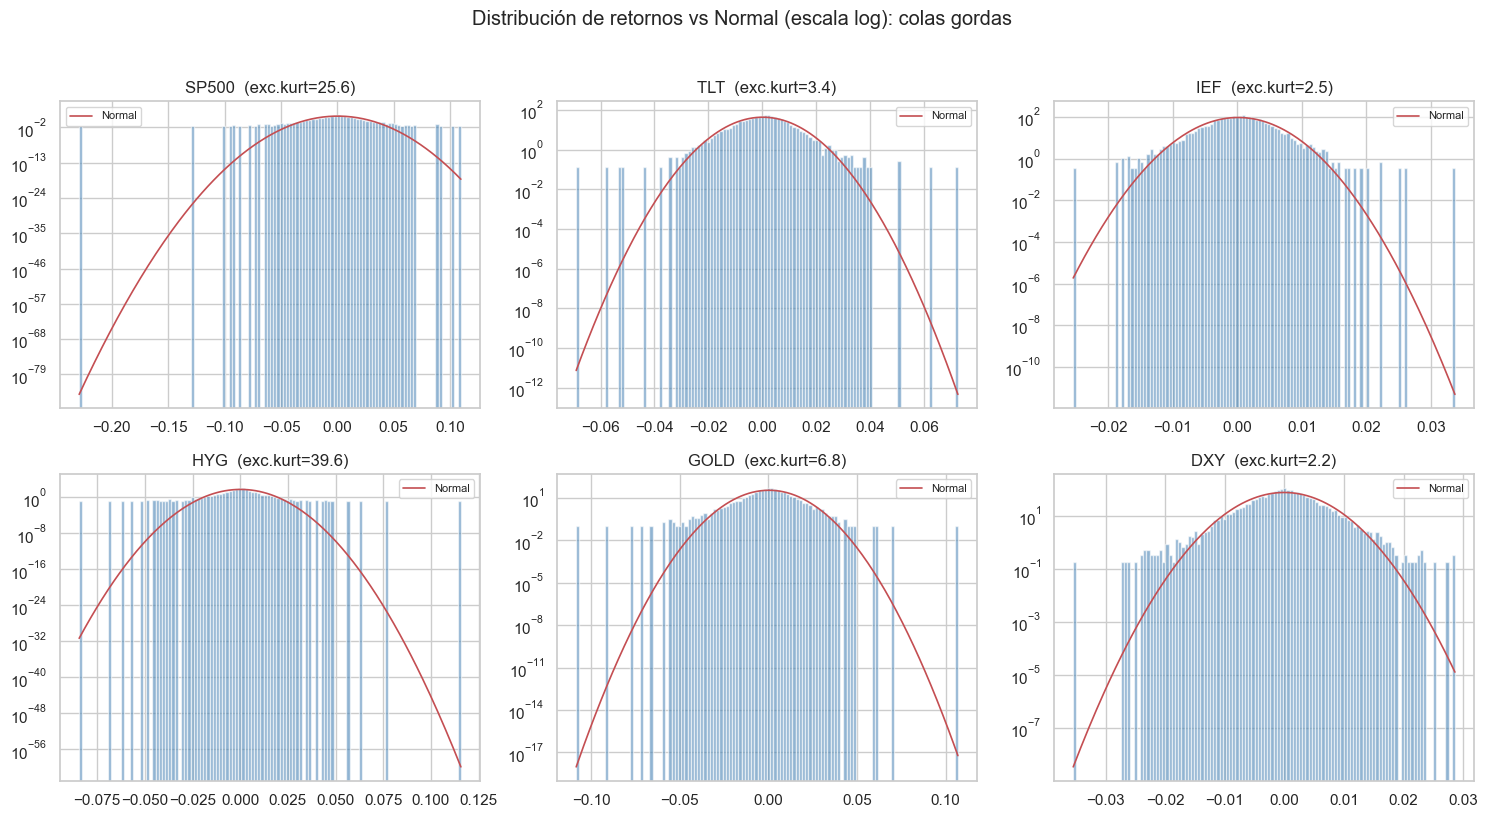

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), px_cols):
    r = rets[c].dropna()
    ax.hist(r, bins=120, density=True, alpha=0.6, color='steelblue')
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', lw=1.2, label='Normal')
    ax.set_title(f'{c}  (exc.kurt={r.kurtosis():.1f})')
    ax.set_yscale('log'); ax.legend(fontsize=8)
fig.suptitle('Distribución de retornos vs Normal (escala log): colas gordas', y=1.02)
fig.tight_layout(); fig.savefig(RESULTS / 'eda_fat_tails.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Correlaciones entre retornos

Estructura de dependencia incondicional. La dependencia condicional al régimen (que sube en crisis) es justo lo que los detectores deben capturar.

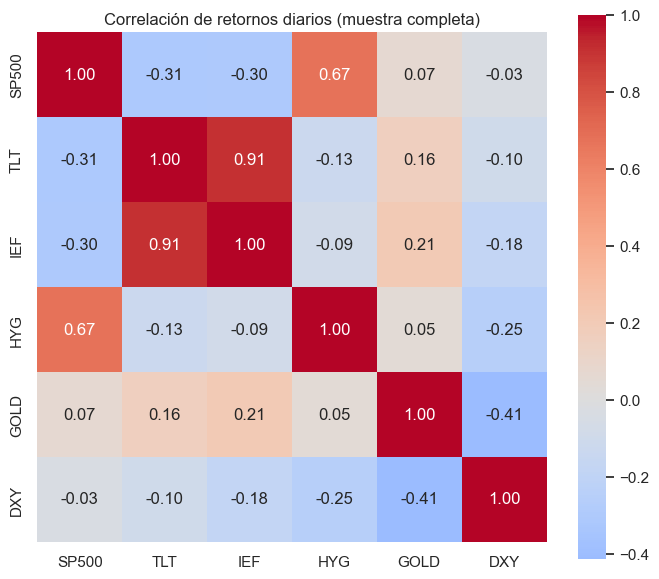

In [8]:
corr = rets.corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlación de retornos diarios (muestra completa)')
fig.tight_layout(); fig.savefig(RESULTS / 'eda_corr.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. S&P 500, drawdown y ventanas de crisis / falsos positivos

Ventanas conocidas (de `evaluation.py`): crisis = 2008/2011/2020/2022; trampas (no-crisis) = taper 2013 y Q4 2018. Todas caen dentro de la ventana común de datos (≥ 2007-04-11).

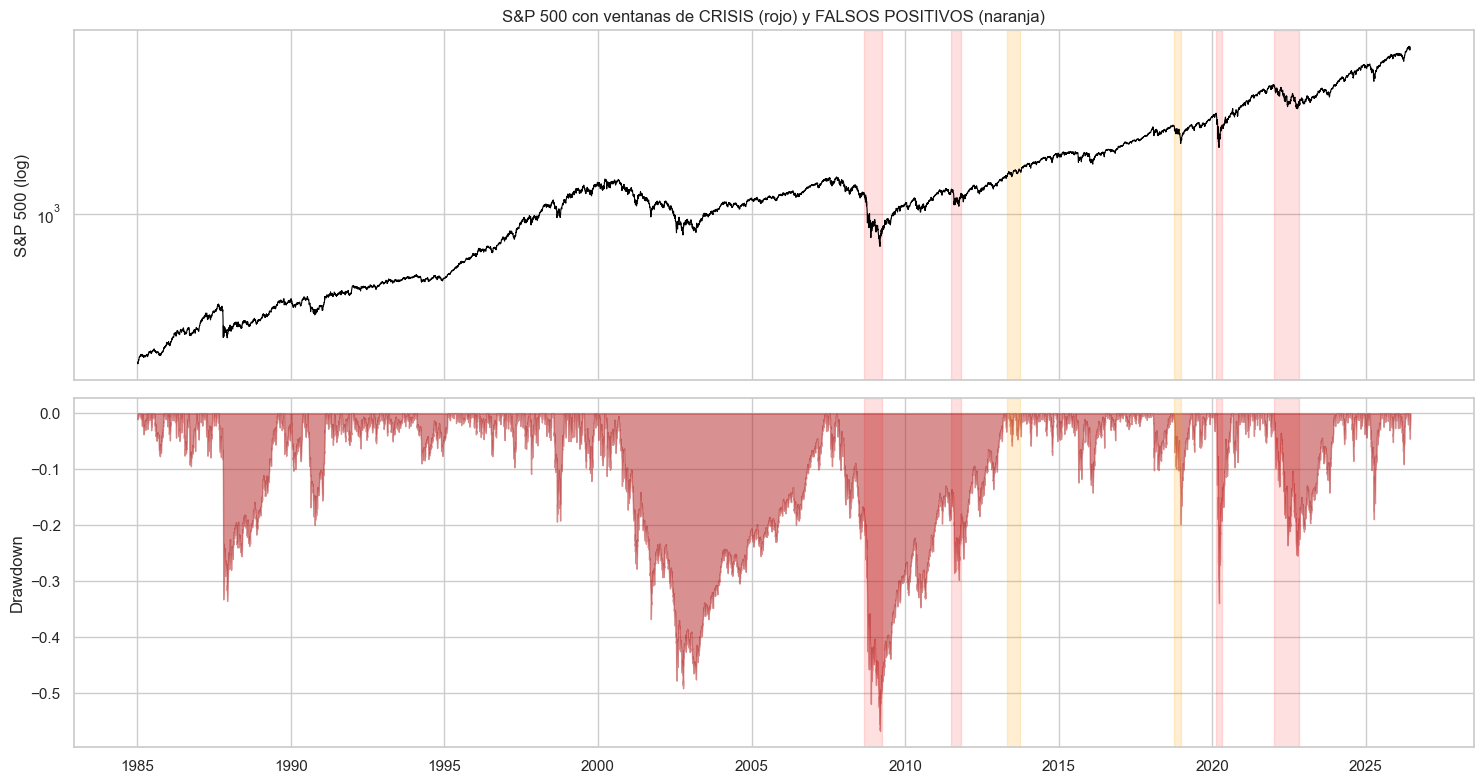

In [9]:
spx = raw['SP500'].dropna()
dd = spx / spx.expanding().max() - 1.0
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
ax1.plot(spx.index, spx, color='black', lw=0.8); ax1.set_yscale('log'); ax1.set_ylabel('S&P 500 (log)')
ax2.fill_between(dd.index, dd, 0, color='firebrick', alpha=0.5); ax2.set_ylabel('Drawdown')
for name, (a, b) in ev.CRISIS_WINDOWS.items():
    for ax in (ax1, ax2): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
    for ax in (ax1, ax2): ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18)
ax1.set_title('S&P 500 con ventanas de CRISIS (rojo) y FALSOS POSITIVOS (naranja)')
fig.tight_layout(); fig.savefig(RESULTS / 'eda_sp500_drawdown.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Suelos de drawdown CALCULADOS (alimentan `DRAWDOWN_TROUGHS`)

Se calculan desde la serie real del S&P 500 (mínimo del drawdown en cada episodio), no a mano. Estos valores están cableados en `evaluation.DRAWDOWN_TROUGHS`.

In [10]:
episodes = {
    'DotCom_2002':   ('2000-01-01','2003-06-30'),
    'GFC_2008':      ('2007-10-01','2009-12-31'),
    'EuroDebt_2011': ('2011-04-01','2012-06-30'),
    'COVID_2020':    ('2020-01-01','2020-06-30'),
    'Inflation_2022':('2022-01-01','2023-06-30'),
}
rows = []
for name, (a, b) in episodes.items():
    seg = dd.loc[a:b]
    rows.append({'episodio': name, 'trough': seg.idxmin().date().isoformat(),
                 'max_drawdown': round(float(seg.min()), 3),
                 'en_ventana_comun': seg.idxmin() >= pd.Timestamp('2007-04-11')})
troughs_df = pd.DataFrame(rows)
print('DRAWDOWN_TROUGHS en evaluation.py:', ev.DRAWDOWN_TROUGHS)
troughs_df

DRAWDOWN_TROUGHS en evaluation.py: {'GFC_2008': '2009-03-09', 'EuroDebt_2011': '2011-10-03', 'COVID_2020': '2020-03-23', 'Inflation_2022': '2022-10-12'}


,episodio,trough,max_drawdown,en_ventana_comun
0,DotCom_2002,2002-10-09,-0.491,False
1,GFC_2008,2009-03-09,-0.568,True
2,EuroDebt_2011,2011-10-03,-0.298,True
3,COVID_2020,2020-03-23,-0.339,True
4,Inflation_2022,2022-10-12,-0.254,True


## 9. Correlación rolling S&P 500 / Treasuries (Gulko 2002)

La correlación equity/bonos **cambia de signo entre regímenes**: suele ser negativa en calma (diversificación) y puede romperse en crisis. Es una feature del detector (`corr_spx_bond`).

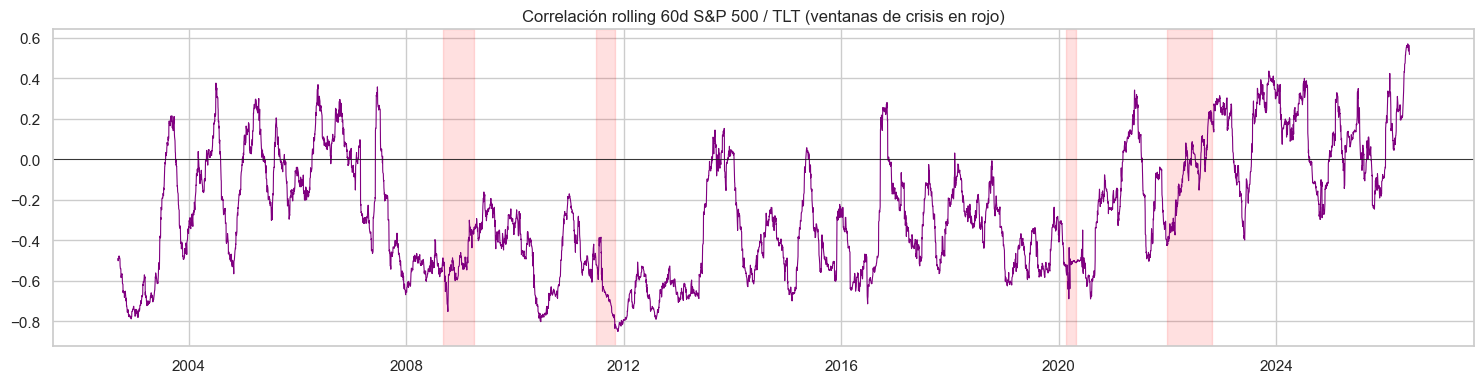

In [11]:
spx_ret = np.log(raw['SP500']/raw['SP500'].shift(1))
tlt_ret = np.log(raw['TLT']/raw['TLT'].shift(1))
rcorr = spx_ret.rolling(60, min_periods=30).corr(tlt_ret).dropna()
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(rcorr.index, rcorr, color='purple', lw=0.8); ax.axhline(0, color='k', lw=0.6)
for name, (a, b) in ev.CRISIS_WINDOWS.items():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
ax.set_title('Correlación rolling 60d S&P 500 / TLT (ventanas de crisis en rojo)')
fig.tight_layout(); fig.savefig(RESULTS / 'eda_rolling_corr.png', dpi=110, bbox_inches='tight')
plt.show()

## 10. Features causales + verificación de no look-ahead

`features.build_features` produce 15 features causales. `assert_causal` trunca la entrada y comprueba que el pasado no cambia al añadir futuro: `max_abs_diff` debe ser 0 para todas.

In [12]:
feats = ft.build_features(raw, save=True)
print('Features:', feats.shape, '| ventana efectiva:', feats.index.min().date(), '->', feats.index.max().date())
feats.describe().T[['mean','std','min','max']].round(3)

Features: (4665, 15) | ventana efectiva: 2007-07-06 -> 2026-06-12


,mean,std,min,max
SP500_ret_z,-0.005,1.097,-11.191,9.142
SP500_vol_z,0.126,1.207,-1.219,8.265
VIX_level_z,0.048,1.149,-1.306,8.769
VIX_change_z,0.012,1.321,-13.031,15.410
MOVE_level_z,-0.137,1.048,-1.548,5.814
TLT_ret_z,-0.014,1.145,-8.042,8.264
IEF_ret_z,-0.018,1.024,-6.131,7.441
HYG_ret_z,-0.002,0.774,-9.366,9.852
credit_spread_z,0.007,0.773,-8.788,8.755
yield_slope_z,-0.416,1.047,-3.078,1.773


In [13]:
causal = ft.assert_causal(raw, cut='2015-01-01')
assert causal['causal_ok'].all(), 'HAY FEATURES NO CAUSALES'
print('TODAS las features son causales (max_abs_diff == 0):')
causal

TODAS las features son causales (max_abs_diff == 0):


,feature,max_abs_diff,causal_ok
0,SP500_ret_z,0.0,True
1,SP500_vol_z,0.0,True
2,VIX_level_z,0.0,True
3,VIX_change_z,0.0,True
4,MOVE_level_z,0.0,True
5,TLT_ret_z,0.0,True
6,IEF_ret_z,0.0,True
7,HYG_ret_z,0.0,True
8,credit_spread_z,0.0,True
9,yield_slope_z,0.0,True


---
**Conclusión FASE 1:** datos descargados sin imputar, ventana común 2007-04-11 → 2026-06 (gobernada por HYG), 15 features causales verificadas, troughs de drawdown calculados. Detalle en `docs/memory/01_data_and_eda.md`.